# Spatial-MicroCKG: Disease-Agnostic Neuroinflammation Infrastructure

## Takeda Panel Demo — Mouse AD Spatial Transcriptomics

**Objective:** Build a reproducible, disease-agnostic pipeline that converts
real Visium spatial transcriptomics data (GEO GSE203424) into a
machine-readable Micro-Clinical Knowledge Graph (Micro-CKG), then queries it
with a local Ollama LLM agent under strict evidence-traceability guardrails.

### Pipeline Steps

| Step | Description |
|------|-------------|
| 1 | **Data Ingestion** — Download 6 samples (3 PSAPP×CO + 3 WT×CO) from GEO |
| 2 | **QC & Normalization** — Standard scanpy preprocessing |
| 3 | **Stabl Feature Selection** — Stratified Downsample → ComBat → DE pre-filter → stability selection |
| 4 | **Marker Visualization** — Spatial overlay or UMAP fallback (incl. Prox1 verification) |
| 5 | **BioCypher Micro-CKG** — Graph construction with DE-filtered edges |
| 6 | **LLM Agent** — Evidence-traced Q&A via Ollama (llama3.1:8b) |

> **Data source:** [GSE203424](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE203424) —
> *Mouse Alzheimer's Disease Spatial Transcriptomics (PSAPP model)*

## 0 · Environment Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure project root is on sys.path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
CACHE_DIR = PROJECT_ROOT / "cache"
ASSETS_DIR = PROJECT_ROOT / "assets"

for d in (DATA_DIR, CACHE_DIR, ASSETS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Cache dir:    {CACHE_DIR}")
print(f"Assets dir:   {ASSETS_DIR}")

Project root: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent
Data dir:     /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/raw
Cache dir:    /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache
Assets dir:   /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets


## 1 · Data Ingestion — GEO GSE203424

Download 6 Corn-Oil-only samples from GEO GSE203424:
- **3 WT × CO (healthy controls):** GSM6171782, GSM6171786, GSM6171790
- **3 PSAPP × CO (Alzheimer's model):** GSM6171784, GSM6171788, GSM6171792

Files are cached locally after the first download.

In [ ]:
from src.data_ingestion import get_dataset
from src.spatial_pipeline import load_adata

h5ad_path = get_dataset(DATA_DIR, source="geo_ad")
adata = load_adata(h5ad_path)

print(f"Dataset: {adata.shape[0]} spots × {adata.shape[1]} genes")
print(f"Samples: {adata.obs['sample_id'].nunique()}")
print(f"Conditions: {dict(adata.obs['condition'].value_counts())}")
adata

## 2 · Quality Control & Normalization

Standard scanpy QC: filter cells/genes, compute mitochondrial fraction,
normalize to 10k counts, log1p transform.

In [3]:
## 3 · Stabl Feature Selection

Pipeline: **Unsupervised Stratified Downsample** (≤1000 spots/sample, Leiden-based) → **ComBat** batch correction →
**t-test DE pre-filter** (FDR < 0.01, |log₂FC| > 0.5) → **Stabl** (L1-LogReg, 500 bootstraps, FDP+ threshold).

Results are cached to disk for reproducibility.

  QC filtering: 24940 → 24922 spots
  Genes retained: 19415
  Normalized to 10000 counts/cell and log1p-transformed
After QC: 24922 spots × 19415 genes


## 3 · Stabl Feature Selection

Pipeline: **Downsample** (≤1000 spots/sample) → **ComBat** batch correction →
**t-test DE pre-filter** (FDR < 0.01, |log₂FC| > 0.5) → **Stabl** (L1-LogReg, 500 bootstraps, FDP+ threshold).

Results are cached to disk for reproducibility.

In [ ]:
from src.spatial_pipeline import run_stabl_cached

stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="geo_ad",
    label_method="condition",
    n_bootstraps=500,
    prefilter="de",
    fdr_alpha=0.01,
    min_log2fc=0.5,
)

print(f"Features selected: {stabl_result['n_selected']}")
print(f"FDP+ threshold:    {stabl_result['threshold']:.4f}")
print(f"Minimum FDP+:      {stabl_result['fdr']:.4f}")

In [5]:
import pandas as pd

df_features = pd.DataFrame({
    "Gene": stabl_result["selected_genes"],
    "Stability_Score": [
        stabl_result["stability_scores"][g]
        for g in stabl_result["selected_genes"]
    ],
}).sort_values("Stability_Score", ascending=False).reset_index(drop=True)

print(f"Top 20 Stabl-selected genes:\n")
df_features.head(20)

Top 20 Stabl-selected genes:



,Gene,Stability_Score
0,Tmbim6,0.986
1,H3f3a,0.984


## 4 · Marker Visualization

Spatial overlay of top Stabl-selected markers plus Prox1 (Hippocampus DG anatomical marker),
Trem2 and Gfap (AD inflammatory markers). Falls back to UMAP embedding
when spatial coordinates are unavailable. Generates a bonus UMAP colored by
condition (WT vs AD).

In [6]:
from src.spatial_pipeline import plot_spatial_markers

top_markers = df_features["Gene"].tolist()
saved_plots = plot_spatial_markers(
    adata,
    markers=top_markers,
    save_dir=ASSETS_DIR,
    n_top=5,
)
print(f"{len(saved_plots)} plots saved to {ASSETS_DIR}")

  Spatial coordinates not available — using UMAP fallback.
  Computing UMAP embedding for fallback visualization...


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  Saved plot: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/umap_Tmbim6.png
  Saved plot: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/umap_H3f3a.png
  Saved plot: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/umap_condition.png
3 plots saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets



umap_Tmbim6.png


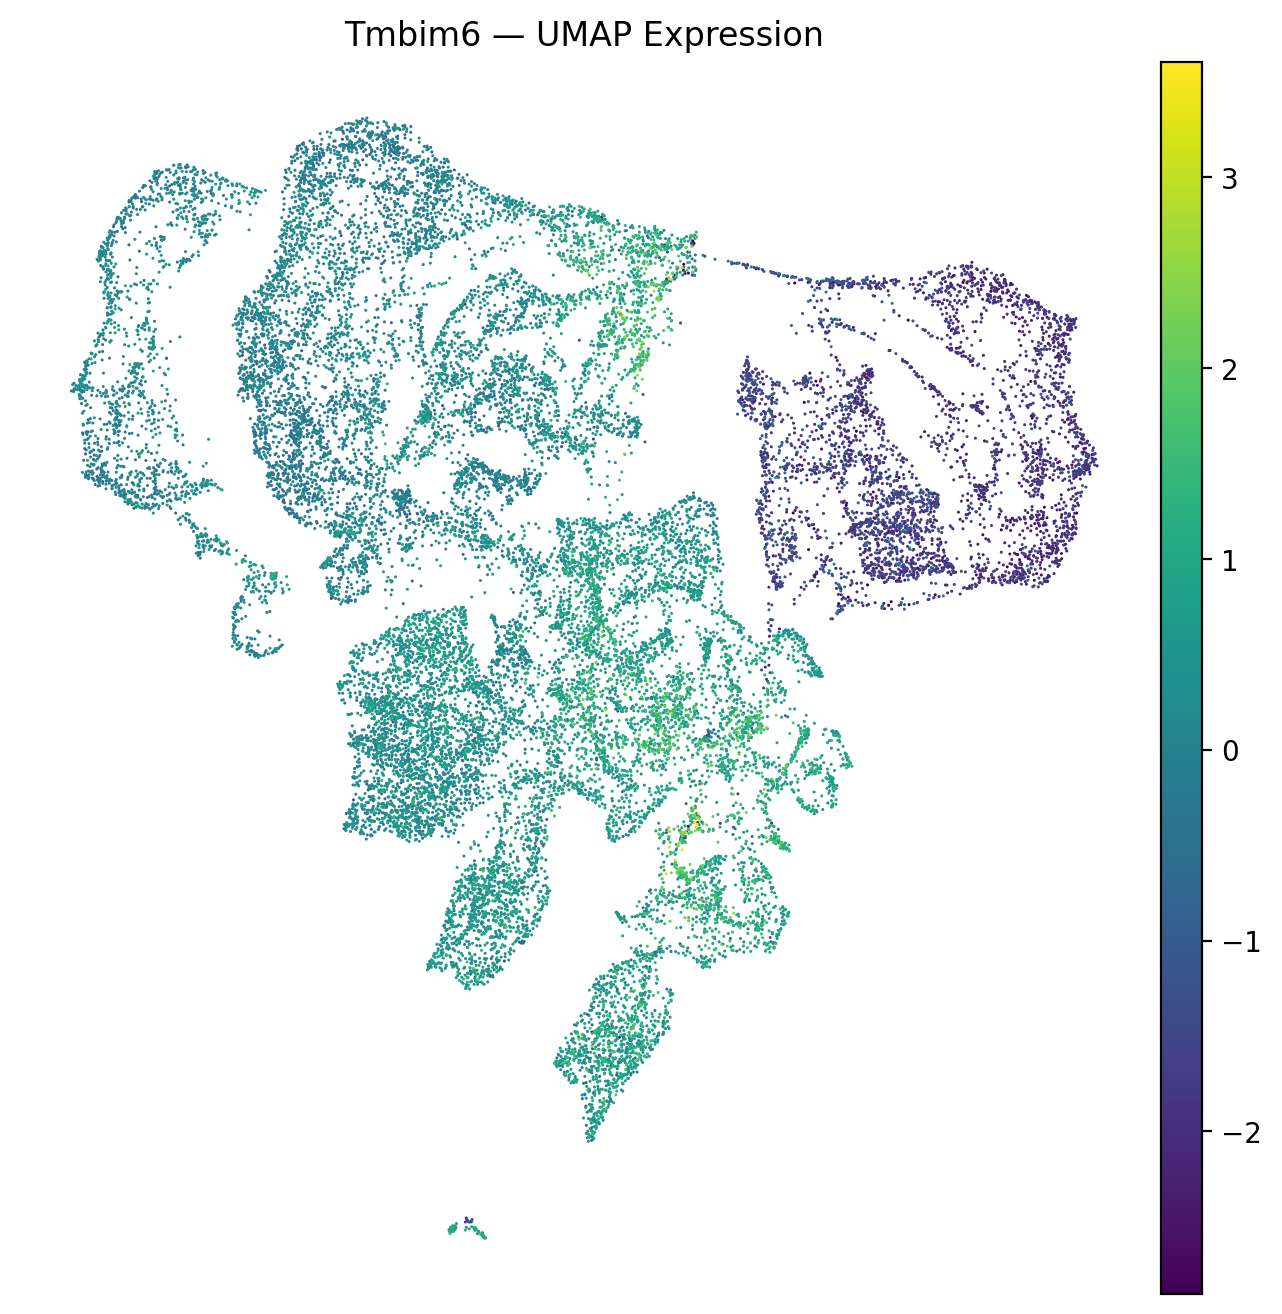


umap_H3f3a.png


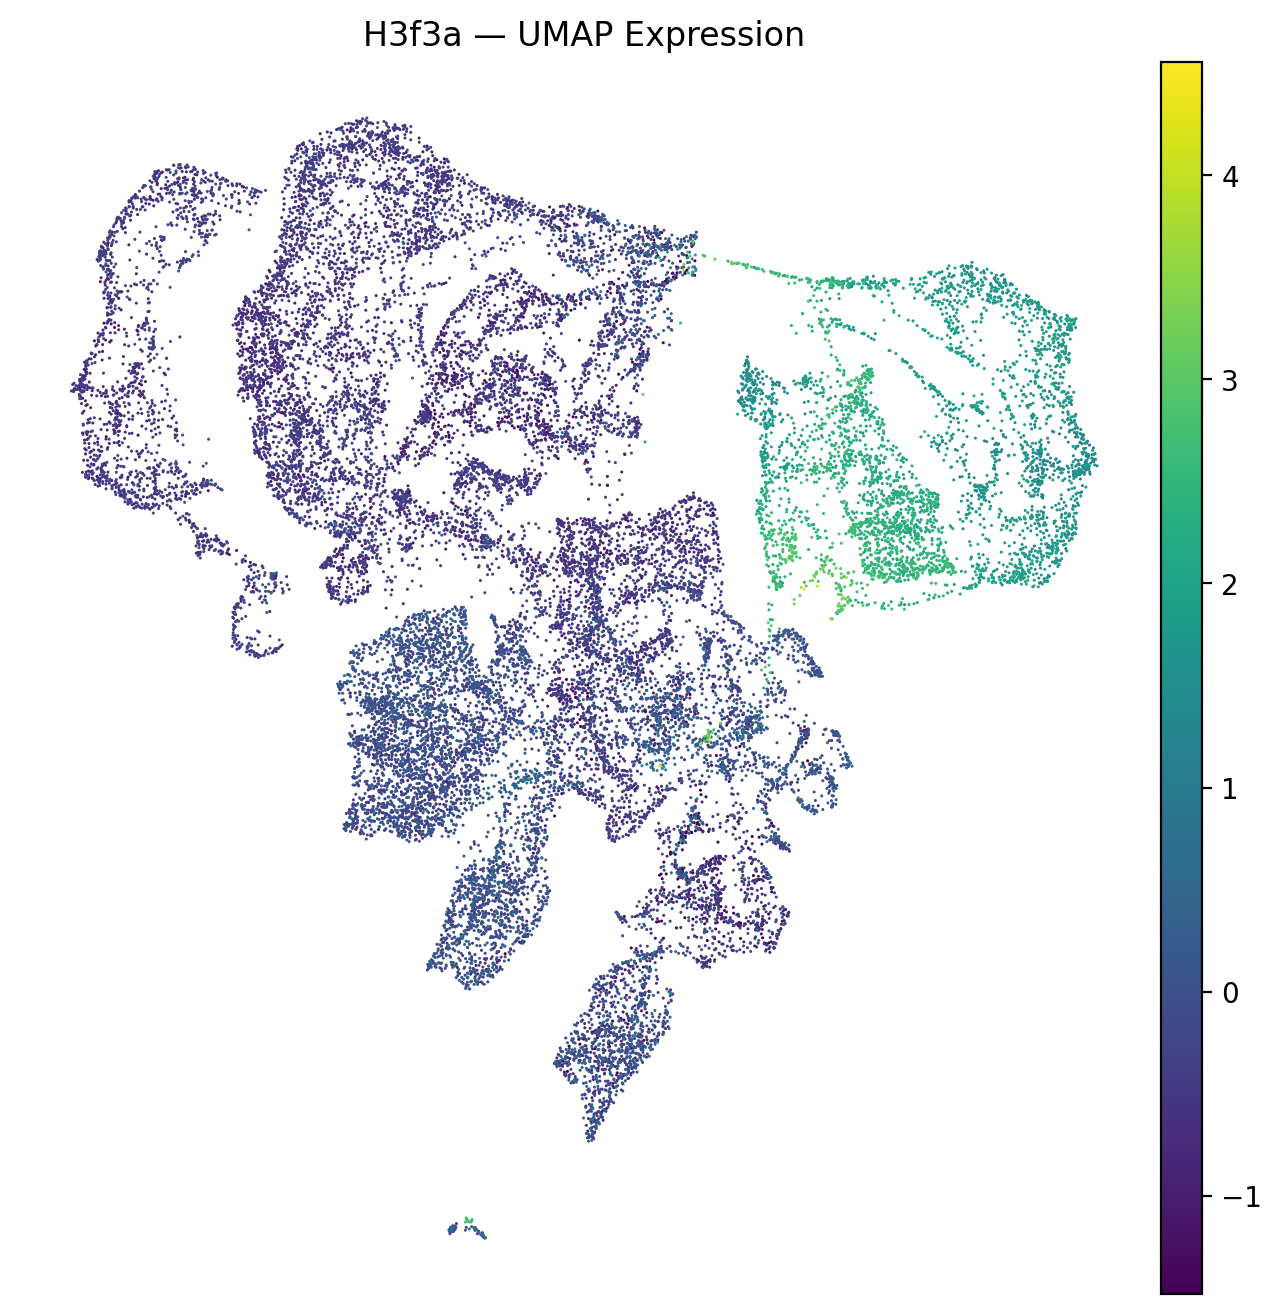


umap_condition.png


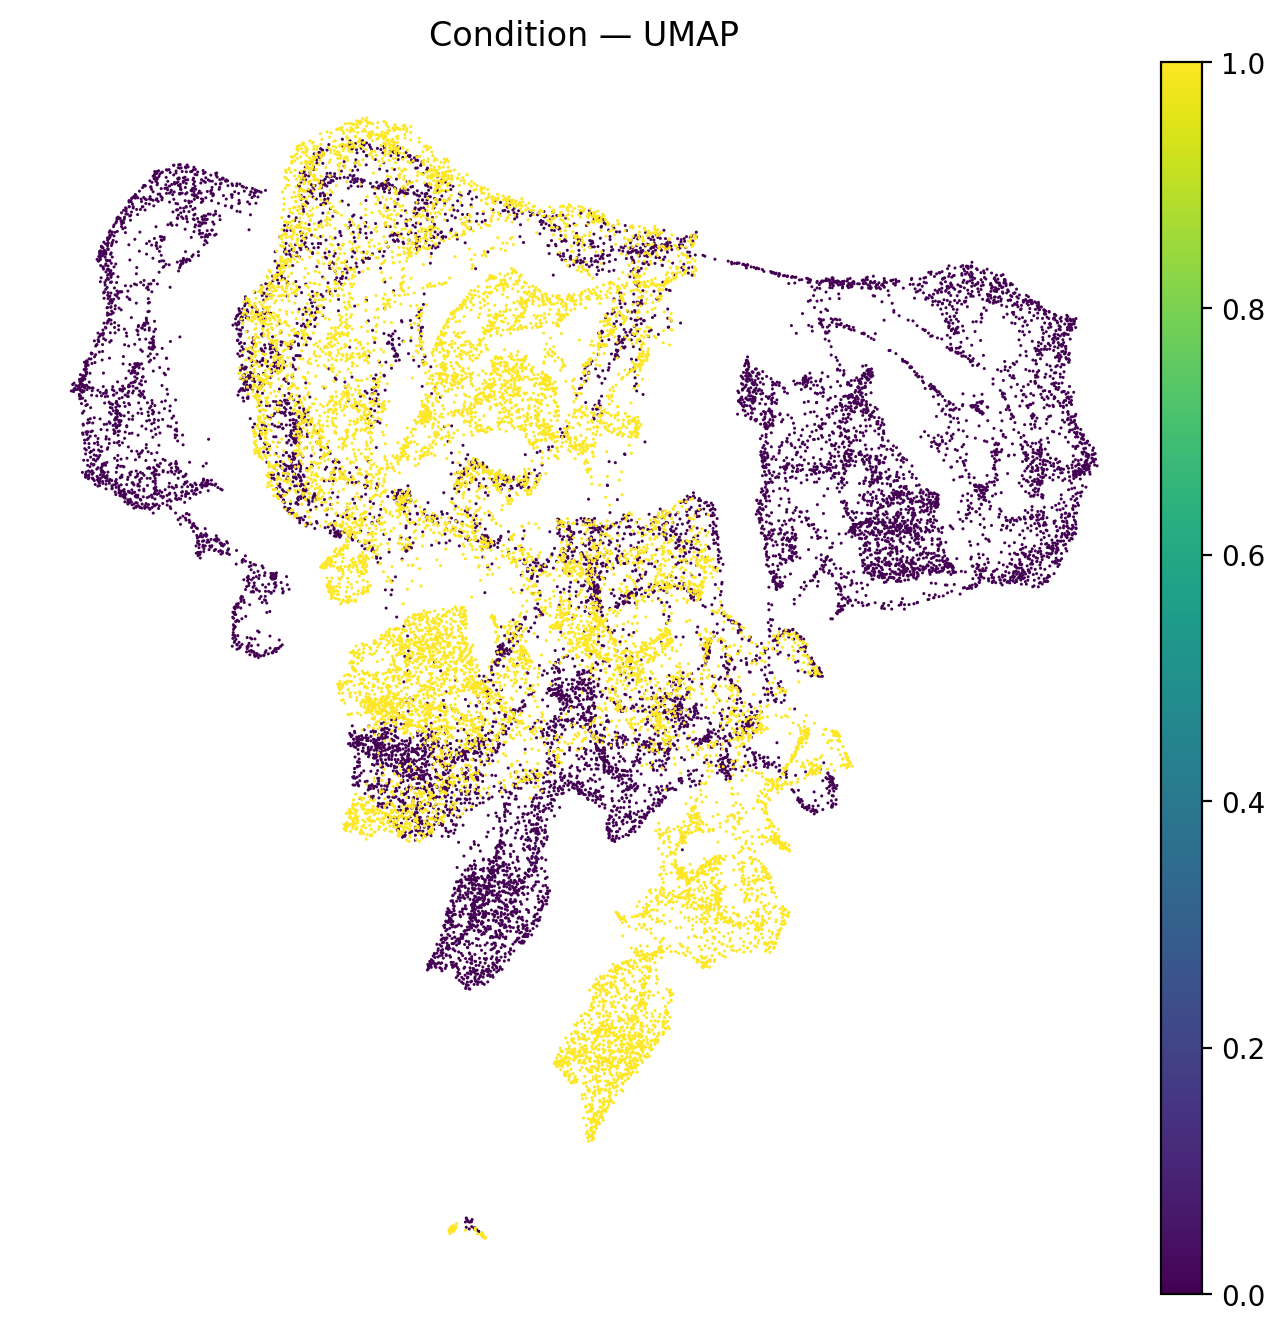

In [7]:
from IPython.display import Image, display

for p in saved_plots[:5]:
    print(f"\n{Path(p).name}")
    display(Image(filename=p, width=600))

## 5 · BioCypher Micro-CKG Construction

Compute Leiden clusters, annotate cell types, then build the knowledge graph.
Edges are filtered by Wilcoxon DE: adjusted p-value < 0.05 and |log₂FC| > 0.5.

In [8]:
from src.spatial_pipeline import compute_clusters, annotate_clusters
from src.biocypher_adapter import build_micro_ckg, save_graph

adata = compute_clusters(adata, n_hvgs=2000)
cluster_annotation = annotate_clusters(adata)

schema_path = PROJECT_ROOT / "config" / "schema_config.yaml"
graph = build_micro_ckg(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
)

graph_path = save_graph(graph, CACHE_DIR / "micro_ckg.graphml")
print(f"Graph saved: {graph_path}")
print(f"Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")

  Selected 2000 highly variable genes (requested 2000)


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  Leiden clustering: 29 clusters
  Cluster annotation: {'White_Matter': np.int64(14), 'Cortex': np.int64(8), 'Striatum': np.int64(7)}
  Running DE testing (Wilcoxon rank-sum)...


/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/shaunfchen/Documents/Repositories/

  DE results: 58 tests, 33 significant
  Building Micro-CKG...
  Micro-CKG: 34 nodes (2 genes, 29 cell types, 3 regions)
  Micro-CKG: 68 edges (DE-filtered)
  Graph saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
Graph saved: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
Nodes: 34, Edges: 68


## 6 · LLM Agent — Evidence-Traced Q&A

Initialize the Ollama LLM agent (`llama3.1:8b`) with 4 hardened guardrails:
1. **No External Knowledge** — answers from graph context only
2. **Missing Data Fallback** — explicit "No evidence found" response
3. **Mandatory Citation** — `[Evidence: (Source) --(Edge)--> (Target)]`
4. **Objective Tone** — no speculation or editorial commentary

In [9]:
from src.llm_agent import create_qa_agent, query_graph

agent = create_qa_agent(graph, provider="ollama")
print("Agent initialized (Ollama — llama3.1:8b)")

Agent initialized (Ollama — llama3.1:8b)


In [ ]:
q1 = "What are the most significant genes associated with the Alzheimer's disease condition in this Micro-CKG?"
print(f"Q: {q1}\n")
a1 = query_graph(agent, q1)
print(a1)

In [11]:
q2 = "Which cell types show the strongest differential gene expression across clusters?"
print(f"Q: {q2}\n")
a2 = query_graph(agent, q2)
print(a2)

Q: Which cell types show the strongest differential gene expression across clusters?

  Querying agent: Which cell types show the strongest differential gene expression across clusters...
Unfortunately, the provided output does not directly show the strongest differential gene expression across clusters. However, we can infer some information from the output.

The output shows the mean expression of gene H3f3a across various cell types, along with the log2 fold change and p-value. We can use this information to identify cell types with strong differential gene expression.

To answer the question, we need to look for cell types with high log2 fold change values (indicating strong differential expression) and low p-values (indicating statistical significance).

From the output, we can see that the following cell types show strong differential expression of gene H3f3a:

* Cluster 23 (White Matter): log2 fold change = 2.3337, p-value = 0.0
* Cluster 24 (Striatum): log2 fold change = 2.5463

In [12]:
q3 = "Are there any neuroinflammation-related pathways represented in this graph?"
print(f"Q: {q3}\n")
a3 = query_graph(agent, q3)
print(a3)

Q: Are there any neuroinflammation-related pathways represented in this graph?

  Querying agent: Are there any neuroinflammation-related pathways represented in this graph?...
To answer this question, we would need to examine the nodes and edges in the graph to see if there are any pathways or relationships related to neuroinflammation.

However, based on the provided output, I can see that there are nodes related to genes (e.g., H3f3a, Tmbim6) and their associations with various cell types and anatomical entities. While this information is useful for understanding the expression and localization of these genes, it does not directly indicate the presence of neuroinflammation-related pathways.

To determine if there are any neuroinflammation-related pathways represented in this graph, we would need to examine the following:

1. Are there any nodes related to inflammatory cytokines, chemokines, or other molecules involved in neuroinflammation?
2. Are there any edges connecting these nod

## Summary

This notebook demonstrated the **Spatial-MicroCKG** pipeline end-to-end:

1. **Real AD data** from GEO GSE203424 (6 Visium samples, Corn-Oil-only)
2. **Unsupervised stratified downsampling** preserving anatomical heterogeneity
3. **Stabl stability selection** to identify reproducible biomarker genes
4. **BioCypher knowledge graph** with DE-filtered gene–cell-type edges
5. **Local LLM agent** (Ollama) with hardened evidence-traceability guardrails

The pipeline is **disease-agnostic** — swap the GEO accession and condition labels
to apply to any spatial transcriptomics dataset.